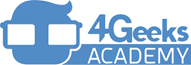

<h1><b>Data Science and Machine Learning</b></h1>
<h2><b>Clase 30</b>: Desplegar modelos IA con Streamlit</h2>
<h3><b>Docente</b>: <a href="https://www.linkedin.com/in/danielablanco/">Daniela Blanco</a>

# Contenido

- [1. Despliegue de modelos](#despliegue)
  - [1.1. Streamlit](#streamlit)
- [2. Características principales Streamlit](#caracteristicas)
- [3. Entorno](#entorno)
- [4. Ejemplos básicos en local](#local)
  - [4.1. Hello](#hello)
  - [4.2. Leyendo datos con cache](#leyendo)
  - [4.3. Visualizador con filtrado](#visualizador)
- [5. Ejemplo de uso remoto con Render](#render)
- [6. Ejemplo de uso remoto con Streamlit share](#sshare)
- [7. Links de interés](#links)


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report

from pickle import dump

import streamlit as st

import warnings

In [ ]:
warnings.filterwarnings("ignore")

## 1. Despliegue de modelos <a name="despliegue"></a>

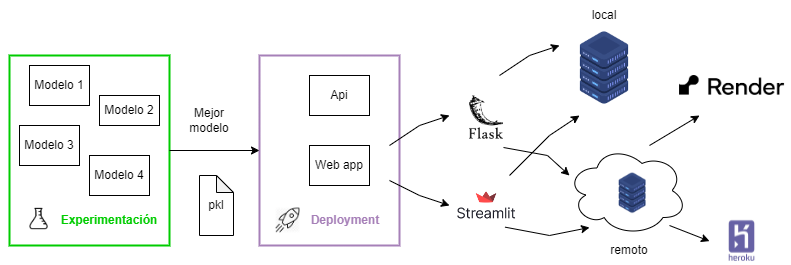

**Deployment** (despliegue en español) es el proceso de hacer que una aplicación o modelo de IA esté disponible para los usuarios finales.

Tras la fase de desarrollo del modelo, tendremos un modelo final según nuestras expectativas y que satisface nuestras necesidades.

Para que este modelo sea útil y cumpla la función para la que ha sido entrenado, debemos ponerlo a disposición en algún entorno que nos permita su utilización.

Un forma de disponibilizarlo es a través de aplicaciones Web o **web app**.

Generalmente las tareas de puesta en producción las hace un perfil de ingeniero de datos. No obstante al científico de datos las herramientas presentadas a contionuación le brindarán una forma rápida de **prototipar** y disponibilizar un desarrollo.

### 1.1. Streamlit <a name="streamlit"></a>

Streamlit es una biblioteca de Python que permite crear aplicaciones web interactivas de forma sencilla.

Fue diseñada pensando en los científicos de datos y desarrolladores, permitiéndoles construir y desplegar aplicaciones web de forma rápida y sencilla, sin necesidad de conocimientos avanzados en desarrollo web.

## 2. Características principales Streamlit <a name="caracteristicas"></a>

**1. Simplicidad**

Permite convertir scripts de datos en aplicaciones web interactivas con solo unas pocas líneas de código.

No requiere el aprendizaje de HTML, CSS o JavaScript.

Todo se hace en Python, lo cual es ideal para científicos de datos y analistas que están más familiarizados con este lenguaje.

**2. Interactividad**

Puedes agregar widgets interactivos como botones, selectores, sliders y formularios con gran facilidad.

Estos componentes permiten a los usuarios interactuar directamente con los datos y obtener resultados en tiempo real.

**3. Actualización Automática**

Cada vez que guardas un cambio en tu script de Streamlit, la aplicación web se actualiza automáticamente.

Esto hace que el proceso de desarrollo sea extremadamente rápido y eficiente.

**4. Almacenamiento en caché**

Streamlit tiene una opción increíble que te permite almacenar en caché los datos y solo ejecutarlos si no se han ejecutado antes. Puedes almacenar en caché cualquier función que crees.

**5. Integración con Herramientas de Ciencia de Datos**

Se integra perfectamente con bibliotecas de ciencia de datos populares como Pandas, NumPy, Matplotlib, Plotly, Seaborn, y muchas otras.

Esto facilita la visualización y el análisis de datos directamente en la aplicación web.

**6. Markdown**

Podemos generar Markdown y README con una sola función.

**7. Despliegue Fácil**

Las aplicaciones creadas con Streamlit pueden ser desplegadas fácilmente en varias plataformas, incluyendo la plataforma de Streamlit, Heroku, AWS, GCP, entre otras.

## 3. Entorno <a name="entorno"></a>

**Creación de un entorno virtual para el uso de la librería**

Crear un entorno virtual en Python es una buena práctica para aislar las dependencias de tu proyecto y evitar conflictos con otras bibliotecas instaladas globalmente.

1. Instalar virtualenv si no lo tienes ya. Puedes hacerlo usando pip:

  `pip install virtualenv`

2. Navega al directorio de tu proyecto y crea un entorno virtual. Puedes nombrar el entorno virtual como desees:

  ```
  cd tu_directorio_del_proyecto
  virtualenv primer_modelo_streamlit
  ```

3. Activar el Entorno Virtual: Para activar el entorno virtual, utiliza los siguientes comandos dependiendo de tu sistema operativo:

  ```
  En Windows:
    primer_modelo_streamlit\Scripts\activate
  En macOS y Linux:
    source primer_modelo_streamlit/bin/activate
  ```

  Una vez activado, deberías ver el nombre del entorno virtual en tu terminal, indicando que está activo.

  Podemos desactivarlo con `deactivate` y luego borrar su carpeta.

**Instalación de librerías**

In [ ]:
pip install streamlit --upgrade

Si da error `ModuleNotFoundError: No module named 'altair.vegalite.v4'` indica que tu entorno de Python no tiene la biblioteca altair instalada.

Altair es una biblioteca de visualización declarativa que se integra con Streamlit para crear gráficos interactivos.

Para resolver este problema, necesitas instalar Altair en su version previa a la 5:

In [ ]:
pip install "altair<5"

Las que vamos a necesitar en los ejemplos:

In [ ]:
pip install plotly

## 4. Ejemplos básicos en local <a name="local"></a>

### 4.1. Hello <a name="hello"></a>

El comando `streamlit hello` es una forma rápida de ver lo que Streamlit puede hacer.

Cuando ejecutas este comando, Streamlit lanza una aplicación de demostración interactiva que muestra varias características y capacidades de la biblioteca.

Para ejecutar la aplicación de demostración, simplemente abre una terminal y escribe el siguiente comando:

In [ ]:
streamlit hello

Ahora puedes ver tu aplicación en su navegador: [http://localhost:8501](http://localhost:8501)

### 4.2. Leyendo datos con cache <a name="leyendo"></a>

En el método `load_data()`, estamos leyendo el archivo .csv usando la librería Pandas y estamos haciendo que nuestro código sea eficiente almacenando en caché los datos.

Si estos datos siguieran cambiando, borramos nuestra memoria caché cada 5 minutos o para un máximo de 20 entradas.

Si los datos no cambian con mucha frecuencia, simplemente podemos usar `@st.cache(persist=True)`. El código anterior es un ejemplo, pero para el modelo Titanic, podríamos mantener persist=True.

Ahora vamos a crear un título, algo de contenido y un menú lateral.

La descripción se muestra en color azul porque usamos HTML para dar el color personalizado como azul. También podemos usar encabezado y subencabezado como usamos st.title() para diferentes encabezados. O podemos usar Markdown para ese propósito.

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px

@st.cache(ttl=60*5, max_entries=20)
def load_data():
    data = pd.read_csv('titanic_train.csv')
    return data

data = load_data()

st.markdown('<style>description{color:blue;}</style>', unsafe_allow_html=True)
st.title('Titanic survival prediction')
st.markdown("<description>The sinking of the Titanic is one of the most infamous shipwrecks in history. " +
"On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding " +
"with an iceberg. Unfortunately, there weren't enough lifeboats for everyone onboard, resulting in the death of " +
"1502 out of 2224 passengers and crew. While there was some element of luck involved in surviving, it seems some " +
"groups of people were more likely to survive than others. </description>", unsafe_allow_html=True)
st.sidebar.title('Select the parameters to analyze survival prediction')

st.write(data)

Una vez que hayas terminado de crear tu propia aplicación, puedes ejecutarla usando:

In [ ]:
streamlit run app_read.py

### 4.3. Visualizador con filtrado <a name="visualizador"></a>


Guarda el siguiente código en un archivo llamado app_visualizador.py.

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np

# Título de la aplicación
st.title('Mi Primera Aplicación con Streamlit')

# Subtítulo
st.header('Visualización de Datos de Ejemplo')

# Crear un DataFrame de ejemplo
data = pd.DataFrame({
    'Número': np.arange(1, 11),
    'Aleatorio': np.random.randn(10)
})

# Mostrar el DataFrame
st.write("Aquí hay algunos datos de ejemplo:")
st.write(data)

# Crear un gráfico de líneas con los datos
st.line_chart(data)

# Slider para seleccionar un valor
valor_seleccionado = st.slider('Selecciona un valor', 0, 10, 5)
st.write('Valor seleccionado:', valor_seleccionado)

# Crear un filtro en el DataFrame basado en el valor seleccionado
filtered_data = data[data['Número'] <= valor_seleccionado]

# Mostrar el DataFrame filtrado
st.write("Datos filtrados hasta el número seleccionado:")
st.write(filtered_data)

# Crear un gráfico de barras con los datos filtrados
st.bar_chart(filtered_data.set_index('Número'))

Para ejecutar la aplicación, abre una terminal, navega hasta el directorio donde guardaste app.py y ejecuta el siguiente comando:

In [ ]:
streamlit run app_visualizador.py

## 5. Ejemplo de uso remoto con Render <a name="render"></a>

**Paso 1: Generar el modelo**

Integraremos el modelo de clasificación que hemos desarrollado en el módulo de los árboles de decisión.

Se trabajo con el dataset iris para predecir el tipo de flor. Siendo la clase 0 una iris setosa, la 1 una iris versicolor y la 2 una iris virginica.

El modelo decision_tree_classifier_default_42.sav se ha guardado en un objeto Pickle de tal forma que pueda ser utilizado para desplegarlo en un servicio web.

In [ ]:
X, y = load_iris(return_X_y = True, as_frame = True)

In [ ]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
# modelo
model = DecisionTreeClassifier(random_state = 42)

# entrenamiento
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# predicción
y_pred_test = model.predict(X_test)
y_pred_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [ ]:
# metricas
accuracy_test = accuracy_score(y_test, y_pred_test)

f1_score_test = f1_score(y_test, y_pred_test, average='micro')

precision_test = precision_score(y_test, y_pred_test, average='micro')

recall_test = recall_score(y_test, y_pred_test, average='micro')

print("Accuracy Test: ", accuracy_test)
print("F1 score Test: ", f1_score_test)
print("Precision Test: ", precision_test)
print("Recall Test: ", recall_test)

Accuracy Test:  1.0
F1 score Test:  1.0
Precision Test:  1.0
Recall Test:  1.0


In [ ]:
print(classification_report(y_test, y_pred_test, target_names=["iris setosa", "iris versicolor", "iris virginica"]))

                 precision    recall  f1-score   support

    iris setosa       1.00      1.00      1.00        10
iris versicolor       1.00      1.00      1.00         9
 iris virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [ ]:
dump(model, open("decision_tree_classifier_default_42.sav", "wb"))

In [ ]:
print(sklearn.__version__)

1.3.2


**Paso 2. Registro en la plataforma**

Para poder acceder a Render debemos tener una cuenta. Para registrarse se debe acceder al siguiente [enlace](https://dashboard.render.com/register).

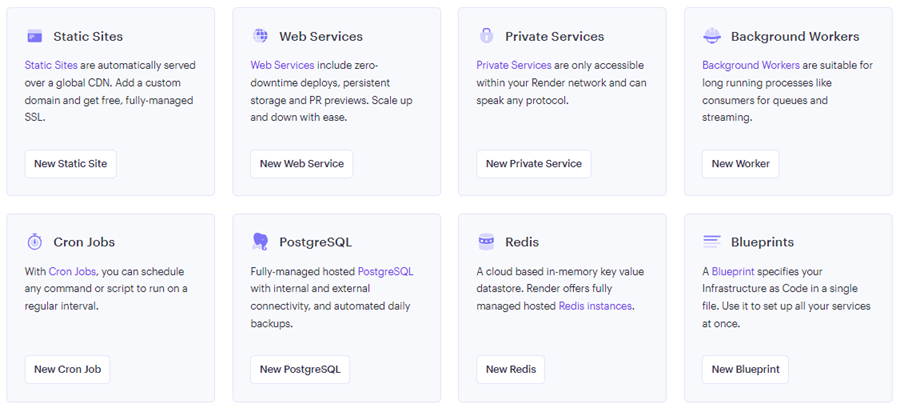

**Paso 3. Crear un repositorio en Git**

Para integrar algo en Render primero debemos haber creado un repositorio en Git. El Git que vamos a generar en esta lección se encuentra [aquí](https://github.com/4GeeksAcademy/streamlit-render-integration), que deriva del Machine Learning Template de 4Geeks.

El codigo de la aplicación (app.py) será:

In [ ]:
from pickle import load
import streamlit as st

model = load(open("../models/decision_tree_classifier_default_42.sav", "rb"))
class_dict = {
    "0": "Iris setosa",
    "1": "Iris versicolor",
    "2": "Iris virginica"
}

st.title("Iris - Model prediction")

val1 = st.slider("Petal width", min_value = 0.0, max_value = 4.0, step = 0.1)
val2 = st.slider("Petal length", min_value = 0.0, max_value = 4.0, step = 0.1)
val3 = st.slider("Sepal width", min_value = 0.0, max_value = 4.0, step = 0.1)
val4 = st.slider("Sepal length", min_value = 0.0, max_value = 4.0, step = 0.1)

if st.button("Predict"):
    prediction = str(model.predict([[val1, val2, val3, val4]])[0])
    pred_class = class_dict[prediction]
    st.write("Prediction:", pred_class)

Con el código anterior conseguimos generar un formulario compuesto por 4 elementos deslizantes (para facilitar la tarea al usuario de introducir el valor) y un botón que lanza la predicción al modelo y lo muestra por pantalla.

**Paso 4: Crear servicio en Render y desplegar la aplicación**

El último paso es configurar el servicio en Render y conectarlo con nuestro repositorio Git. Recomendado darle permiso solo a los repositorios que queremos de forma individual.

Debemos ir al Dashboard de Render, seleccionar el apartado de `Web Services` y elegir el repositorio en el que hayamos subido todo el código y las carpetas anteriores.

Una vez lo seleccionemos nos aparecerá un formulario como el siguiente:

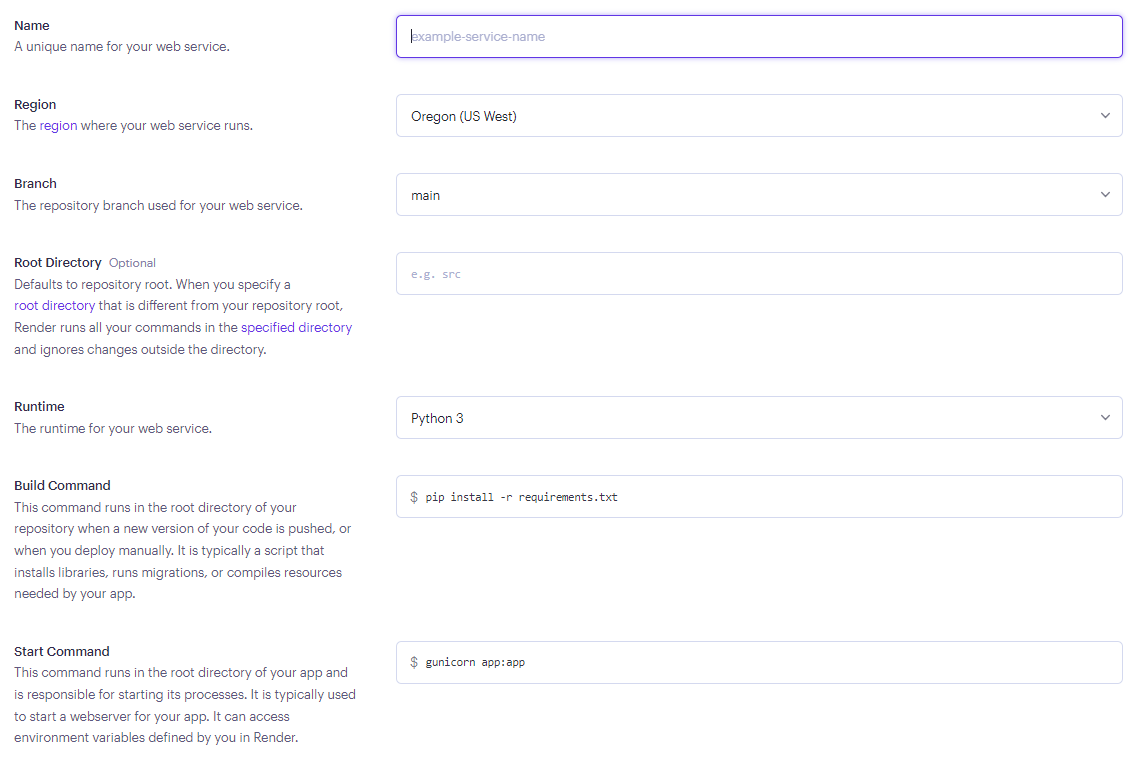

Deberemos rellenarlo con la siguiente información:

- Name: El nombre que queramos que tenga nuestro servicio. Por ejemplo: streamlit-render-integration

- Language: El código es Python, así que dejaremos el valor por defecto, Python 3.

- Branch: La rama en la que se encuentra nuestro código actualizado. Deberemos dejar el valor por defecto, main.

- Root Directory: En este caso hemos desarrollado el código dentro de la carpeta `src`, por lo que deberemos introducir `src`.

- Build Command: Dejaremos el valor por defecto, pip install -r requirements.txt.

- Start Command: streamlit run app.py.

Por último, elegiremos la tarifa gratuita.

En el siguiente paso nos aparecerá una consola con los registros (logs) del despliegue de la aplicación. El despliegue se hace paso a paso, clonando en primer lugar el repositorio, construyéndolo (build), instalando las dependencias, y, en último lugar, ejecutando el comando para lanzar la aplicación web.

**Paso 4: Uso del servicio en Render**

Una vez que el despliegue ha sido satisfactorio, accedemos a la aplicación desde el enlace situado debajo del nombre del servicio, y ya podemos utilizar la aplicación.

La que hemos creado en esta lección está accesible en el siguiente enlace: [https://streamlit-render-integration-j98j.onrender.com](https://streamlit-render-integration-j98j.onrender.com).

Probar predicciones:
- Petal width 2.5
- Petal length: 1.2
- Sepal Width: 2.7
- Sepal length: 1.5

## 6. Ejemplo de uso remoto con Streamlit share <a name="sshare"></a>

**Paso 1. Registro en la plataforma**

Para poder acceder a Render debemos tener una cuenta. Para registrarse se debe acceder al siguiente [enlace](https://share.streamlit.io/signup).

**Paso 2. Crear un repositorio en Git**

**Paso 3: Crear una app en Streamlit**

La primea vez pedirá acceso a github.

Creamos una nueva app, deberemos rellenarlo con la siguiente información:

- Repository: seleccioanmos el repositorio del proyecto.

- Branch: La rama en la que se encuentra nuestro código actualizado. Deberemos dejar el valor por defecto, main.

- Main file path: `src/app.py`.

**Nota**: Dejando el repositorio tal cual daba error al acceder al modelo por no reconocer la subcarpeta. Aparentemente la aplicación share de Streamlit espera tener en raiz el archivo principal.

Está accesible en el siguiente enlace con el repo original: [https://app-render-integration-db.streamlit.app/](https://app-render-integration-db.streamlit.app/).

En este otro el que funciona [https://app-share-integration-db.streamlit.app/](https://app-share-integration-db.streamlit.app/).

## 7. Links de interés <a name="links"></a>

- [Documentación Oficial de Streamlit](https://docs.streamlit.io/)
- [Construyendo y Desplegando tu Dashboard en la Nube: Una Guía Completa con Streamlit y Plotly](https://medium.com/datapath/construyendo-y-desplegando-tu-dashboard-en-la-nube-una-gu%C3%ADa-completa-con-streamlit-y-plotly-936cc1c8c71d)
- [Develop GenAI Apps with Gemini and Streamlit](https://www.cloudskillsboost.google/paths/236/course_templates/978)